# Linear Algebra for Deep Learning

**Why this notebook exists:** Every DL operation — a forward pass, a weight update, an attention score — is linear algebra. Most DL tutorials assume you know this. We teach it.

**What you will be able to do after this notebook:**
- Read any DL paper's equation section without getting stuck on notation
- Understand why matrix shapes must match in PyTorch and debug shape errors instantly
- Derive the weight update rule for any layer from scratch
- Understand PCA, SVD, and attention — they are all eigendecomposition in disguise

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/00_math/linear_algebra.ipynb)

---

## Table of Contents
1. [Scalars, Vectors, Matrices, Tensors](#1-scalars-vectors-matrices-tensors)
2. [Matrix Operations](#2-matrix-operations)
3. [Matrix Multiplication — the most important operation in DL](#3-matrix-multiplication)
4. [Norms — measuring size of vectors and matrices](#4-norms)
5. [Special Matrices](#5-special-matrices)
6. [Eigenvalues and Eigenvectors](#6-eigenvalues-and-eigenvectors)
7. [Singular Value Decomposition (SVD)](#7-singular-value-decomposition)
8. [How These Show Up in Deep Learning](#8-how-these-show-up-in-deep-learning)
9. [Visual Intuition — Interactive Diagrams](#9-visual-intuition)
10. [Exercises](#10-exercises)


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

print('NumPy version:', np.__version__)


NumPy version: 2.0.2


## 1. Scalars, Vectors, Matrices, Tensors

These are the four data types of deep learning. Everything is one of these.

| Name | Shape | Notation | DL example |
|---|---|---|---|
| **Scalar** | () | $x \in \mathbb{R}$ | A single loss value |
| **Vector** | (n,) | $\mathbf{x} \in \mathbb{R}^n$ | One training sample, one word embedding |
| **Matrix** | (m, n) | $X \in \mathbb{R}^{m \times n}$ | A batch of samples, a weight matrix |
| **Tensor** | (d1, d2, ..., dk) | $\mathcal{X}$ | A batch of images (batch, C, H, W) |

**Shape convention in DL:**

- Vectors are **column vectors** by default: $\mathbf{x} \in \mathbb{R}^{n \times 1}$
- A batch of $m$ samples: $X \in \mathbb{R}^{m \times d}$ — rows are samples, columns are features
- Weight matrix $W \in \mathbb{R}^{d_{\text{out}} \times d_{\text{in}}}$ — output dim first


In [2]:
# Scalar
s = np.float64(3.14)
print(f'Scalar: {s}  |  shape: {np.array(s).shape}  |  ndim: {np.array(s).ndim}')

# Vector — 1D array
v = np.array([1.0, 2.0, 3.0, 4.0])
print(f'Vector: {v}  |  shape: {v.shape}  |  ndim: {v.ndim}')

# Matrix — 2D array
M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)
print(f'Matrix shape: {M.shape}  |  ndim: {M.ndim}')
print(M)

# Tensor — 3D+ array
# Simulating a batch of 32 RGB images 64x64
T = np.random.randn(32, 3, 64, 64)
print(f'\nTensor (batch of images) shape: {T.shape}  |  ndim: {T.ndim}')
print('Interpretation: 32 samples, 3 channels, 64 height, 64 width')


Scalar: 3.14  |  shape: ()  |  ndim: 0
Vector: [1. 2. 3. 4.]  |  shape: (4,)  |  ndim: 1
Matrix shape: (3, 3)  |  ndim: 2
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

Tensor (batch of images) shape: (32, 3, 64, 64)  |  ndim: 4
Interpretation: 32 samples, 3 channels, 64 height, 64 width


### Indexing and Slicing — critical for debugging shape errors

The most common DL bug is a shape mismatch. Knowing how to inspect and slice tensors is the first debugging skill.


In [3]:
M = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]], dtype=float)

print('Full matrix M:')
print(M)

print(f'\nM[0]     = {M[0]}          <- row 0 (first sample in a batch)')
print(f'M[:, 0]  = {M[:, 0]}   <- col 0 (first feature across all samples)')
print(f'M[1, 2]  = {M[1, 2]}           <- single element (row 1, col 2)')

# This is exactly how nn.Linear works internally
# X has shape (batch_size, in_features)
# W has shape (out_features, in_features)
# output = X @ W.T  ->  (batch_size, out_features)
batch_size, in_features, out_features = 4, 3, 2
X = np.random.randn(batch_size, in_features)
W = np.random.randn(out_features, in_features)
b = np.random.randn(out_features)

output = X @ W.T + b   # this IS nn.Linear
print(f'\nX shape:      {X.shape}  (batch=4, features=3)')
print(f'W shape:      {W.shape}  (out=2, in=3)')
print(f'W.T shape:    {W.T.shape}  (in=3, out=2)')
print(f'X @ W.T:      {(X @ W.T).shape}  (batch=4, out=2) <- correct!')
print(f'output shape: {output.shape}')


Full matrix M:
[[10. 20. 30.]
 [40. 50. 60.]
 [70. 80. 90.]]

M[0]     = [10. 20. 30.]          <- row 0 (first sample in a batch)
M[:, 0]  = [10. 40. 70.]   <- col 0 (first feature across all samples)
M[1, 2]  = 60.0           <- single element (row 1, col 2)

X shape:      (4, 3)  (batch=4, features=3)
W shape:      (2, 3)  (out=2, in=3)
W.T shape:    (3, 2)  (in=3, out=2)
X @ W.T:      (4, 2)  (batch=4, out=2) <- correct!
output shape: (4, 2)


## 2. Matrix Operations

### Transpose

$$A^T_{ij} = A_{ji}$$

Swaps rows and columns. Shape $(m, n) \to (n, m)$.

Used everywhere: `W.T` in the linear layer forward pass, converting row vectors to column vectors.

### Element-wise operations (Hadamard product)

$$[A \odot B]_{ij} = A_{ij} \cdot B_{ij}$$

Requires identical shapes. Used in LSTM gates (gate ⊙ candidate), attention masking.

### Broadcasting

Allows operations between arrays of different shapes by implicitly expanding dimensions. Rule: align shapes from the right, dimensions are compatible if equal or one of them is 1.

```
(batch, features) + (features,)  →  adds bias to every sample in batch
(batch, seq, d_model) + (seq, d_model)  →  adds position embedding to every sample
```


In [4]:
A = np.array([[1, 2, 3],
              [4, 5, 6]], dtype=float)  # (2, 3)
B = np.array([[7, 8, 9],
              [1, 2, 3]], dtype=float)  # (2, 3)

print('A:')
print(A)
print('\nA.T (transpose):')
print(A.T, '  shape:', A.T.shape)

print('\nA + B (element-wise add):')
print(A + B)

print('\nA * B (Hadamard product — element-wise multiply):')
print(A * B)

# Broadcasting — adding a bias vector to a batch
bias = np.array([10, 20, 30])  # shape (3,)
print('\nA + bias (broadcasting — adds same bias to each row):')
print(A + bias)
print('This is what nn.Linear does: output = X @ W.T + bias')


A:
[[1. 2. 3.]
 [4. 5. 6.]]

A.T (transpose):
[[1. 4.]
 [2. 5.]
 [3. 6.]]   shape: (3, 2)

A + B (element-wise add):
[[ 8. 10. 12.]
 [ 5.  7.  9.]]

A * B (Hadamard product — element-wise multiply):
[[ 7. 16. 27.]
 [ 4. 10. 18.]]

A + bias (broadcasting — adds same bias to each row):
[[11. 22. 33.]
 [14. 25. 36.]]
This is what nn.Linear does: output = X @ W.T + bias


## 3. Matrix Multiplication — the Most Important Operation in DL

$$C = AB \quad \text{where} \quad C_{ij} = \sum_{k} A_{ik} B_{kj}$$

Shape rule: $(m \times n) \cdot (n \times p) \to (m \times p)$ — **inner dimensions must match**.

**Why it matters:** Every layer in a neural network is a matrix multiplication.

$$\text{Linear layer: } Y = XW^T + \mathbf{b}$$
$$\text{Attention: } \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
$$\text{RNN: } h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

### The dot product interpretation

Each element $C_{ij}$ is the **dot product** of row $i$ of $A$ with column $j$ of $B$:

$$C_{ij} = \mathbf{a}_i^T \mathbf{b}_j = \sum_k a_{ik} b_{kj}$$

High dot product = high similarity between row $i$ and column $j$. This is exactly how attention computes similarity between queries and keys.


In [5]:
A = np.array([[1, 2],
              [3, 4],
              [5, 6]], dtype=float)  # (3, 2)

B = np.array([[7, 8, 9],
              [1, 2, 3]], dtype=float)  # (2, 3)

C = A @ B  # (3,2) @ (2,3) -> (3,3)

print(f'A shape: {A.shape}')
print(f'B shape: {B.shape}')
print(f'C = A @ B shape: {C.shape}')
print('\nC:')
print(C)

# Verify C[0, 0] manually = dot(A[0], B[:, 0])
manual = np.dot(A[0], B[:, 0])
print(f'\nC[0,0] = dot(A[0], B[:,0]) = {A[0]} · {B[:, 0]} = {manual}')
print(f'Matches C[0,0]: {np.isclose(C[0,0], manual)}')


A shape: (3, 2)
B shape: (2, 3)
C = A @ B shape: (3, 3)

C:
[[ 9. 12. 15.]
 [25. 32. 39.]
 [41. 52. 63.]]

C[0,0] = dot(A[0], B[:,0]) = [1. 2.] · [7. 1.] = 9.0
Matches C[0,0]: True


In [6]:
# The dot product measures similarity — foundation of attention
print('=== Dot product as similarity ===')

# Query vector (what I am looking for)
query = np.array([1.0, 0.0, 0.0])  # looking for 'x-axis direction'

# Key vectors (what each memory slot contains)
keys = np.array([
    [1.0, 0.0, 0.0],   # key 0: matches query perfectly
    [0.0, 1.0, 0.0],   # key 1: orthogonal — no match
    [0.7, 0.7, 0.0],   # key 2: partial match
    [-1.0, 0.0, 0.0],  # key 3: opposite direction
])

# Dot product scores
scores = keys @ query   # (4, 3) @ (3,) -> (4,)
softmax_scores = np.exp(scores) / np.exp(scores).sum()

print('Query:', query)
print()
for i, (k, s, sm) in enumerate(zip(keys, scores, softmax_scores)):
    print(f'Key {i}: {k}  |  score: {s:+.2f}  |  attention weight: {sm:.4f}')

print('\nKey 0 gets all the attention — it matches the query perfectly.')
print('This IS the attention mechanism in transformers.')


=== Dot product as similarity ===
Query: [1. 0. 0.]

Key 0: [1. 0. 0.]  |  score: +1.00  |  attention weight: 0.4456
Key 1: [0. 1. 0.]  |  score: +0.00  |  attention weight: 0.1639
Key 2: [0.7 0.7 0. ]  |  score: +0.70  |  attention weight: 0.3301
Key 3: [-1.  0.  0.]  |  score: -1.00  |  attention weight: 0.0603

Key 0 gets all the attention — it matches the query perfectly.
This IS the attention mechanism in transformers.


In [7]:
# Batched matrix multiplication — how PyTorch processes sequences
print('=== Batched matmul (used in transformers for Q, K, V) ===')

# Batch of 2 sequences, each with 3 tokens, each token is 4-dim
batch_size, seq_len, d_model = 2, 3, 4
Q = np.random.randn(batch_size, seq_len, d_model)  # queries
K = np.random.randn(batch_size, seq_len, d_model)  # keys

# Compute attention scores for all sequences in batch simultaneously
# Q: (B, seq, d)  K.transpose: (B, d, seq)  ->  (B, seq, seq)
scores = Q @ K.transpose(0, 2, 1)  # transpose last two dims

print(f'Q shape:      {Q.shape}')
print(f'K.T shape:    {K.transpose(0, 2, 1).shape}')
print(f'scores shape: {scores.shape}  <- attention matrix for each sample')
print('Each scores[b, i, j] = similarity of token i attending to token j in sample b')


=== Batched matmul (used in transformers for Q, K, V) ===
Q shape:      (2, 3, 4)
K.T shape:    (2, 4, 3)
scores shape: (2, 3, 3)  <- attention matrix for each sample
Each scores[b, i, j] = similarity of token i attending to token j in sample b


## 4. Norms — Measuring Size of Vectors and Matrices

A norm $\|\cdot\|$ is a function that assigns a non-negative scalar to a vector, measuring its 'magnitude' or 'size'.

### Vector Norms

**L1 norm (Manhattan):**
$$\|\mathbf{x}\|_1 = \sum_i |x_i|$$

**L2 norm (Euclidean) — the default:**
$$\|\mathbf{x}\|_2 = \sqrt{\sum_i x_i^2} = \sqrt{\mathbf{x}^T \mathbf{x}}$$

**L$\infty$ norm (max):**
$$\|\mathbf{x}\|_\infty = \max_i |x_i|$$

### Why Norms Matter in DL

| DL use | Norm | Reason |
|---|---|---|
| L2 regularization | $\|W\|_2^2$ | Penalizes large weights, prevents overfit |
| L1 regularization (Lasso) | $\|W\|_1$ | Drives weights to zero (sparsity) |
| Gradient clipping | $\|g\|_2$ | Rescale gradient when it exceeds threshold |
| Attention scaling | $\sqrt{d_k}$ | Scale dot products to prevent softmax saturation |
| Weight initialization | $\|W\|$ | He/Xavier init sets variance based on layer size |

### Frobenius Norm (for matrices)

$$\|A\|_F = \sqrt{\sum_i \sum_j A_{ij}^2} = \sqrt{\text{tr}(A^T A)}$$

The natural extension of L2 norm to matrices. Used in weight decay for matrices.


In [8]:
x = np.array([3.0, -4.0, 0.0, 1.0, -2.0])

l1   = np.sum(np.abs(x))
l2   = np.sqrt(np.sum(x**2))
linf = np.max(np.abs(x))

print(f'Vector x: {x}')
print(f'L1 norm:  {l1:.4f}  (sum of |x_i|)')
print(f'L2 norm:  {l2:.4f}  (Euclidean distance from origin)')
print(f'Linf norm:{linf:.4f}  (max |x_i|)')

# Verify with numpy
print(f'\nnp.linalg.norm(x, 1):   {np.linalg.norm(x, 1):.4f}')
print(f'np.linalg.norm(x):      {np.linalg.norm(x):.4f}   (default is L2)')
print(f'np.linalg.norm(x, np.inf): {np.linalg.norm(x, np.inf):.4f}')


Vector x: [ 3. -4.  0.  1. -2.]
L1 norm:  10.0000  (sum of |x_i|)
L2 norm:  5.4772  (Euclidean distance from origin)
Linf norm:4.0000  (max |x_i|)

np.linalg.norm(x, 1):   10.0000
np.linalg.norm(x):      5.4772   (default is L2)
np.linalg.norm(x, np.inf): 4.0000


In [9]:
# Gradient clipping — exactly how PyTorch does it
def clip_gradient(grad, max_norm):
    grad_norm = np.linalg.norm(grad)   # L2 norm of gradient vector
    if grad_norm > max_norm:
        grad = grad * (max_norm / grad_norm)  # rescale to max_norm
    return grad, grad_norm

# Simulate a gradient that has exploded
large_grad  = np.array([100.0, -200.0, 150.0, -50.0])
clipped, norm_before = clip_gradient(large_grad, max_norm=1.0)

print('Gradient before clipping:', large_grad)
print(f'Gradient norm before:    {norm_before:.4f}')
print('Gradient after clipping: ', clipped.round(4))
print(f'Gradient norm after:     {np.linalg.norm(clipped):.4f}')
print('Direction preserved:', np.allclose(clipped / np.linalg.norm(clipped),
                                           large_grad / norm_before))

# This is torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print('\nIn PyTorch: torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)')


Gradient before clipping: [ 100. -200.  150.  -50.]
Gradient norm before:    273.8613
Gradient after clipping:  [ 0.3651 -0.7303  0.5477 -0.1826]
Gradient norm after:     1.0000
Direction preserved: True

In PyTorch: torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)


## 5. Special Matrices

These matrices appear constantly in DL proofs and implementations.

| Matrix | Definition | DL appearance |
|---|---|---|
| **Identity** $I$ | $I_{ij} = 1$ if $i=j$, else 0 | Residual connections: $H(x) + Ix$ |
| **Symmetric** | $A = A^T$ | Covariance matrices, Gram matrices |
| **Orthogonal** | $Q^T Q = QQ^T = I$ | Weight init, SVD components |
| **Diagonal** | $D_{ij} = 0$ for $i \neq j$ | Scaling, batch norm (γ, β) |
| **Positive definite** | $\mathbf{x}^T A \mathbf{x} > 0$ for all $\mathbf{x} \neq 0$ | Covariance matrices, Hessians |

### Matrix Inverse

$$A A^{-1} = A^{-1} A = I$$

Exists only when $A$ is square and full rank (determinant ≠ 0). In DL:
- Normal equation: $w^* = (X^T X)^{-1} X^T y$
- Attention scaling: we never actually invert — we use softmax instead
- Most DL systems avoid explicit matrix inversion (numerically unstable for large matrices)

### Trace

$$\text{tr}(A) = \sum_i A_{ii}$$

Sum of diagonal elements = sum of eigenvalues. Used in: Frobenius norm, some loss functions in generative models.


In [10]:
# Identity matrix
I3 = np.eye(3)
print('Identity matrix I_3:')
print(I3)

A = np.array([[2., 1.], [5., 3.]])
A_inv = np.linalg.inv(A)
print('\nA:')
print(A)
print('A_inv:')
print(A_inv)
print('A @ A_inv (should be I):')
print((A @ A_inv).round(10))

# Orthogonal matrix — columns are orthonormal vectors
Q, _ = np.linalg.qr(np.random.randn(3, 3))
print('\nOrthogonal matrix Q (from QR decomposition):')
print(Q.round(4))
print('Q.T @ Q (should be I):')
print((Q.T @ Q).round(10))
print('Orthogonal matrices preserve vector norms — used in weight init')


Identity matrix I_3:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

A:
[[2. 1.]
 [5. 3.]]
A_inv:
[[ 3. -1.]
 [-5.  2.]]
A @ A_inv (should be I):
[[ 1.  0.]
 [-0.  1.]]

Orthogonal matrix Q (from QR decomposition):
[[-0.7796  0.5548 -0.2904]
 [-0.6256 -0.7102  0.3227]
 [-0.0272  0.4333  0.9008]]
Q.T @ Q (should be I):
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]
Orthogonal matrices preserve vector norms — used in weight init


## 6. Eigenvalues and Eigenvectors

For a square matrix $A$, a vector $\mathbf{v}$ is an **eigenvector** with **eigenvalue** $\lambda$ if:

$$A\mathbf{v} = \lambda \mathbf{v}$$

The matrix $A$ only **scales** the vector $\mathbf{v}$ — it doesn't rotate it.

**Eigendecomposition:** A symmetric matrix $A$ can be decomposed as:

$$A = Q \Lambda Q^T$$

where $Q$ is an orthogonal matrix of eigenvectors (columns) and $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_n)$ is diagonal with eigenvalues.

### Why Eigenvalues Matter in DL

**1. PCA** — Principal components are eigenvectors of the covariance matrix $\Sigma = X^T X / (m-1)$. The eigenvalue $\lambda_k$ is the variance explained by component $k$.

**2. Understanding gradient flow** — The eigenvalues of the weight matrix Jacobian determine whether gradients explode ($|\lambda| > 1$) or vanish ($|\lambda| < 1$) during backprop.

**3. Attention** — The attention matrix $\text{softmax}(QK^T / \sqrt{d_k})$ is a learned projection into directions (eigenvectors) that best align queries and keys.

**4. Optimizer theory** — The Hessian $H = \nabla^2 L$ eigenvalues determine the curvature of the loss surface. Large eigenvalues = sharp direction (needs small lr). Small = flat direction.


In [11]:
# Eigendecomposition of a symmetric matrix
A = np.array([[4., 2.],
              [2., 3.]])

eigenvalues, eigenvectors = np.linalg.eigh(A)  # eigh for symmetric matrices

print('Matrix A:')
print(A)
print(f'\nEigenvalues:  {eigenvalues}')
print(f'Eigenvectors (columns):')
print(eigenvectors)

# Verify A v = lambda v for each eigenvector
for i in range(2):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    Av  = A @ v
    lv  = lam * v
    print(f'\nEigenvector {i}: {v.round(4)}')
    print(f'A @ v = {Av.round(4)}')
    print(f'λ × v = {lv.round(4)}')
    print(f'Match: {np.allclose(Av, lv)}')

# Reconstruct A from eigendecomposition
Q, lam = eigenvectors, np.diag(eigenvalues)
A_reconstructed = Q @ lam @ Q.T
print(f'\nA reconstructed from Q Λ Q^T:')
print(A_reconstructed)
print(f'Matches original: {np.allclose(A, A_reconstructed)}')


Matrix A:
[[4. 2.]
 [2. 3.]]

Eigenvalues:  [1.4384 5.5616]
Eigenvectors (columns):
[[ 0.6154 -0.7882]
 [-0.7882 -0.6154]]

Eigenvector 0: [ 0.6154 -0.7882]
A @ v = [ 0.8852 -1.1338]
λ × v = [ 0.8852 -1.1338]
Match: True

Eigenvector 1: [-0.7882 -0.6154]
A @ v = [-4.3836 -3.4226]
λ × v = [-4.3836 -3.4226]
Match: True

A reconstructed from Q Λ Q^T:
[[4. 2.]
 [2. 3.]]
Matches original: True


In [12]:
# PCA from eigendecomposition — the manual way
np.random.seed(42)

# Generate correlated 2D data
mean   = [2, 3]
cov    = [[2.0, 1.5], [1.5, 1.5]]   # correlated features
X_data = np.random.multivariate_normal(mean, cov, 200)

# Step 1: center the data
X_c = X_data - X_data.mean(axis=0)

# Step 2: covariance matrix
Sigma = (X_c.T @ X_c) / (len(X_c) - 1)
print('Covariance matrix Σ:')
print(Sigma.round(4))

# Step 3: eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
idx = np.argsort(eigenvalues)[::-1]   # sort descending
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f'\nPrincipal components (eigenvectors):')
print(eigenvectors)
print(f'\nExplained variance (eigenvalues): {eigenvalues}')
print(f'Variance explained by PC1: {eigenvalues[0]/eigenvalues.sum():.1%}')
print(f'Variance explained by PC2: {eigenvalues[1]/eigenvalues.sum():.1%}')

# Step 4: project to PC1
X_projected = X_c @ eigenvectors[:, :1]  # (200, 2) @ (2, 1) -> (200, 1)
print(f'\nProjected shape: {X_projected.shape}')


Covariance matrix Σ:
[[1.8138 1.3782]
 [1.3782 1.4002]]

Principal components (eigenvectors):
[[-0.7578  0.6525]
 [-0.6525 -0.7578]]

Explained variance (eigenvalues): [3.0007 0.2133]
Variance explained by PC1: 93.4%
Variance explained by PC2: 6.6%

Projected shape: (200, 1)


## 7. Singular Value Decomposition (SVD)

SVD is the most general matrix decomposition. Every matrix $A \in \mathbb{R}^{m \times n}$ can be decomposed as:

$$A = U \Sigma V^T$$

where:
- $U \in \mathbb{R}^{m \times m}$ — orthogonal matrix, columns are **left singular vectors**
- $\Sigma \in \mathbb{R}^{m \times n}$ — diagonal matrix of **singular values** $\sigma_1 \geq \sigma_2 \geq \dots \geq 0$
- $V \in \mathbb{R}^{n \times n}$ — orthogonal matrix, columns are **right singular vectors**

**Relationship to eigendecomposition:**
$$A^T A = V \Sigma^T U^T U \Sigma V^T = V (\Sigma^T \Sigma) V^T$$

The right singular vectors $V$ are the eigenvectors of $A^T A$, and the singular values satisfy $\sigma_k^2 = \lambda_k$.

### Why SVD Is Everywhere in DL

**PCA** — sklearn's PCA uses SVD directly: $\tilde{X} = U \Sigma V^T$, principal components = columns of $V$

**Low-rank approximation** — keep only top-$k$ singular values: $A \approx U_k \Sigma_k V_k^T$. This is the foundation of LoRA (Low-Rank Adaptation) for fine-tuning LLMs.

**Weight initialization** — orthogonal initialization uses $U$ or $V$ from SVD

**Spectral normalization** — divides weight matrix by its largest singular value $\sigma_1$ to control Lipschitz constant — used in GAN training


In [13]:
A = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [7., 8., 9.],
              [1., 3., 5.]], dtype=float)  # (4, 3) non-square

U, S, Vt = np.linalg.svd(A, full_matrices=False)

print(f'A shape:  {A.shape}')
print(f'U shape:  {U.shape}  (left singular vectors)')
print(f'S shape:  {S.shape}  (singular values)')
print(f'Vt shape: {Vt.shape} (right singular vectors transposed)')
print(f'\nSingular values: {S.round(4)}')

# Reconstruct A
A_reconstructed = U @ np.diag(S) @ Vt
print(f'\nReconstruction error: {np.linalg.norm(A - A_reconstructed):.2e}')


A shape:  (4, 3)
U shape:  (4, 3)  (left singular vectors)
S shape:  (3,)  (singular values)
Vt shape: (3, 3) (right singular vectors transposed)

Singular values: [17.7425  2.2811  0.    ]

Reconstruction error: 3.26e-15


=== Low-Rank Approximation (foundation of LoRA) ===


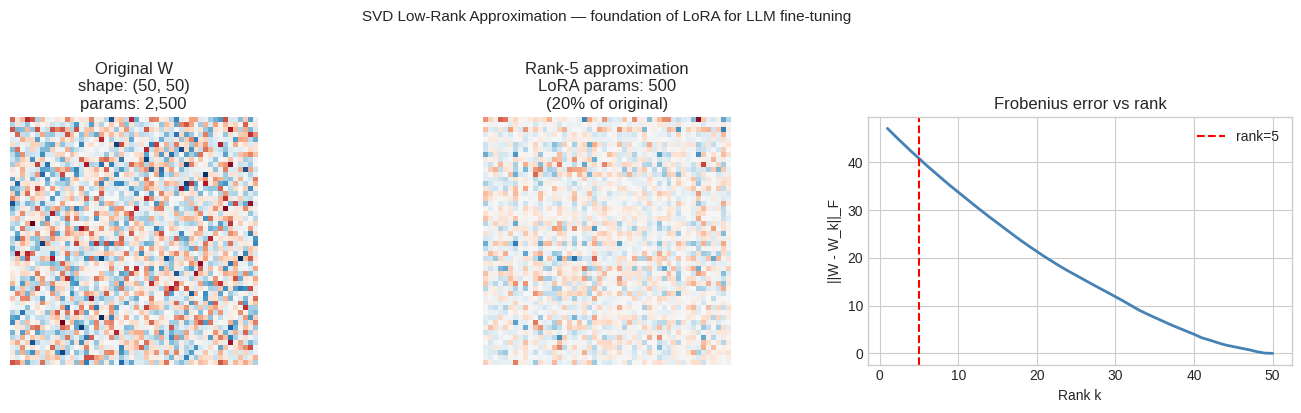

Original W: 2,500 parameters
LoRA rank-5: U(50,5) + Vt(5,50) = 500 parameters
Parameter reduction: 80%


In [14]:
# Low-rank approximation — the foundation of LoRA
print('=== Low-Rank Approximation (foundation of LoRA) ===')

# Imagine a large weight matrix
np.random.seed(0)
W = np.random.randn(50, 50)

U, S, Vt = np.linalg.svd(W, full_matrices=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Original weight matrix
axes[0].imshow(W, cmap='RdBu_r', vmin=-3, vmax=3)
axes[0].set_title(f'Original W\nshape: {W.shape}\nparams: {W.size:,}')
axes[0].axis('off')

# Approximations with different ranks
errors = []
ranks = range(1, 51)
for k in ranks:
    W_approx = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    errors.append(np.linalg.norm(W - W_approx, 'fro'))

# Rank-5 approximation
k = 5
W_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
axes[1].imshow(W_k, cmap='RdBu_r', vmin=-3, vmax=3)
params_lora = 50*k + k*50
axes[1].set_title(f'Rank-{k} approximation\nLoRA params: {params_lora}\n'
                  f'({params_lora/W.size:.0%} of original)')
axes[1].axis('off')

# Error vs rank
axes[2].plot(list(ranks), errors, color='steelblue', linewidth=2)
axes[2].axvline(k, color='red', linestyle='--', linewidth=1.5, label=f'rank={k}')
axes[2].set_title('Frobenius error vs rank')
axes[2].set_xlabel('Rank k'); axes[2].set_ylabel('||W - W_k||_F')
axes[2].legend()

plt.suptitle('SVD Low-Rank Approximation — foundation of LoRA for LLM fine-tuning',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'Original W: {W.size:,} parameters')
print(f'LoRA rank-{k}: U({50},{k}) + Vt({k},{50}) = {params_lora} parameters')
print(f'Parameter reduction: {1 - params_lora/W.size:.0%}')


## 8. How These Show Up in Deep Learning

This section connects every concept above to a concrete DL equation.


In [15]:
print('=== Linear Layer (nn.Linear) ===')
print('  forward:  y = X W^T + b')
print('  X: (batch, in_features)')
print('  W: (out_features, in_features)')
print('  b: (out_features,)')
print('  y: (batch, out_features)')
print()

# Implement nn.Linear from scratch
class LinearScratch:
    def __init__(self, in_f, out_f):
        # He initialization: W ~ N(0, 2/in_f)
        self.W = np.random.randn(out_f, in_f) * np.sqrt(2.0 / in_f)
        self.b = np.zeros(out_f)

    def forward(self, X):
        # X: (batch, in_f)  W: (out_f, in_f)  -> (batch, out_f)
        return X @ self.W.T + self.b

layer = LinearScratch(4, 3)
X_in  = np.random.randn(8, 4)   # batch=8, features=4
out   = layer.forward(X_in)
print(f'Input:  {X_in.shape}')
print(f'W:      {layer.W.shape}')
print(f'Output: {out.shape}')


=== Linear Layer (nn.Linear) ===
  forward:  y = X W^T + b
  X: (batch, in_features)
  W: (out_features, in_features)
  b: (out_features,)
  y: (batch, out_features)

Input:  (8, 4)
W:      (3, 4)
Output: (8, 3)


In [16]:
print('=== Scaled Dot-Product Attention ===')
print('  Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V')
print()

def softmax(x, axis=-1):
    x_max = x.max(axis=axis, keepdims=True)
    e_x   = np.exp(x - x_max)   # subtract max for numerical stability
    return e_x / e_x.sum(axis=axis, keepdims=True)

def attention_scratch(Q, K, V):
    d_k    = Q.shape[-1]
    # Step 1: QK^T  ->  (seq, seq)
    scores = Q @ K.transpose(0, 2, 1)   # batched transpose
    # Step 2: scale
    scores = scores / np.sqrt(d_k)
    # Step 3: softmax
    weights = softmax(scores, axis=-1)
    # Step 4: weighted sum of values
    output  = weights @ V
    return output, weights

B, seq, d_k, d_v = 2, 5, 8, 8
Q = np.random.randn(B, seq, d_k)
K = np.random.randn(B, seq, d_k)
V = np.random.randn(B, seq, d_v)

out, weights = attention_scratch(Q, K, V)
print(f'Q shape:       {Q.shape}')
print(f'K shape:       {K.shape}')
print(f'V shape:       {V.shape}')
print(f'Output shape:  {out.shape}')
print(f'Weights shape: {weights.shape}  <- attention matrix')
print(f'Weights sum (each row should sum to 1): {weights[0].sum(axis=-1).round(4)}')


=== Scaled Dot-Product Attention ===
  Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V

Q shape:       (2, 5, 8)
K shape:       (2, 5, 8)
V shape:       (2, 5, 8)
Output shape:  (2, 5, 8)
Weights shape: (2, 5, 5)  <- attention matrix
Weights sum (each row should sum to 1): [1. 1. 1. 1. 1.]


In [17]:
print('=== Gradient Flow Through a Linear Layer ===')
print('During backprop, gradients flow through matrix multiplications.')
print()

# Forward: Y = X W^T + b
# Loss L = some_function(Y)
# Backward: given dL/dY, compute dL/dW, dL/db, dL/dX

# Chain rule:
# dL/dW = (dL/dY)^T X           -- gradient w.r.t. weights
# dL/db = sum(dL/dY, axis=0)    -- gradient w.r.t. bias (sum over batch)
# dL/dX = (dL/dY) W             -- gradient w.r.t. input (for prev layer)

class LinearWithBackprop:
    def __init__(self, in_f, out_f):
        self.W  = np.random.randn(out_f, in_f) * np.sqrt(2.0 / in_f)
        self.b  = np.zeros(out_f)
        self.X  = None   # cache input for backward

    def forward(self, X):
        self.X = X   # cache
        return X @ self.W.T + self.b

    def backward(self, dL_dY):
        # dL_dY: (batch, out_f)
        dL_dW = dL_dY.T @ self.X          # (out_f, batch) @ (batch, in_f) = (out_f, in_f)
        dL_db = dL_dY.sum(axis=0)          # (out_f,)
        dL_dX = dL_dY @ self.W             # (batch, out_f) @ (out_f, in_f) = (batch, in_f)
        return dL_dW, dL_db, dL_dX

layer = LinearWithBackprop(4, 3)
X_in     = np.random.randn(8, 4)
Y        = layer.forward(X_in)
dL_dY    = np.ones_like(Y) / Y.size   # fake upstream gradient
dL_dW, dL_db, dL_dX = layer.backward(dL_dY)

print(f'dL/dY shape:  {dL_dY.shape}')
print(f'dL/dW shape:  {dL_dW.shape}  <- same as W')
print(f'dL/db shape:  {dL_db.shape}  <- same as b')
print(f'dL/dX shape:  {dL_dX.shape}  <- same as X (passed to previous layer)')


=== Gradient Flow Through a Linear Layer ===
During backprop, gradients flow through matrix multiplications.

dL/dY shape:  (8, 3)
dL/dW shape:  (3, 4)  <- same as W
dL/db shape:  (3,)  <- same as b
dL/dX shape:  (8, 4)  <- same as X (passed to previous layer)


## 9. Visual Intuition — Interactive Diagrams

/tmp/ipykernel_1618/3724092948.py:43: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


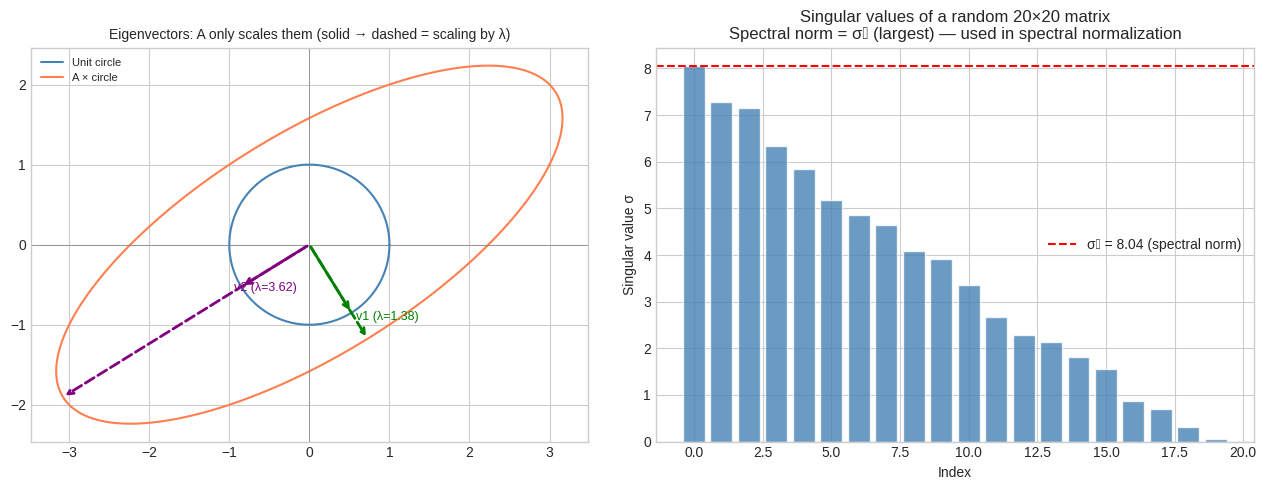

In [18]:
# ── Plot 1: Eigenvectors — geometric interpretation ──────────────────────
A = np.array([[3., 1.], [1., 2.]])
eigenvalues, eigenvectors = np.linalg.eigh(A)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Draw unit circle and its transformation under A
theta = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(theta), np.sin(theta)])      # (2, 200)
ellipse = A @ circle                                     # (2, 200) — A stretches circle

axes[0].plot(circle[0], circle[1], 'steelblue', linewidth=1.5, label='Unit circle')
axes[0].plot(ellipse[0], ellipse[1], 'coral', linewidth=1.5, label='A × circle')

# Draw eigenvectors
for i, color in enumerate(['green', 'purple']):
    v   = eigenvectors[:, i]
    lam = eigenvalues[i]
    axes[0].annotate('', xy=v, xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=color, lw=2))
    axes[0].annotate('', xy=lam*v, xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=color, lw=2, linestyle='dashed'))
    axes[0].text(v[0]*1.1, v[1]*1.1, f'v{i+1} (λ={lam:.2f})', color=color, fontsize=9)

axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_aspect('equal')
axes[0].set_title('Eigenvectors: A only scales them (solid → dashed = scaling by λ)', fontsize=10)
axes[0].legend(fontsize=8)

# Singular values of a matrix
np.random.seed(1)
W_vis = np.random.randn(20, 20)
_, S_vis, _ = np.linalg.svd(W_vis)
axes[1].bar(range(len(S_vis)), S_vis, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('Singular values of a random 20×20 matrix\n'
                   'Spectral norm = σ₁ (largest) — used in spectral normalization')
axes[1].set_xlabel('Index'); axes[1].set_ylabel('Singular value σ')
axes[1].axhline(S_vis[0], color='red', linestyle='--', linewidth=1.5,
                label=f'σ₁ = {S_vis[0]:.2f} (spectral norm)')
axes[1].legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_1618/3428220522.py:44: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


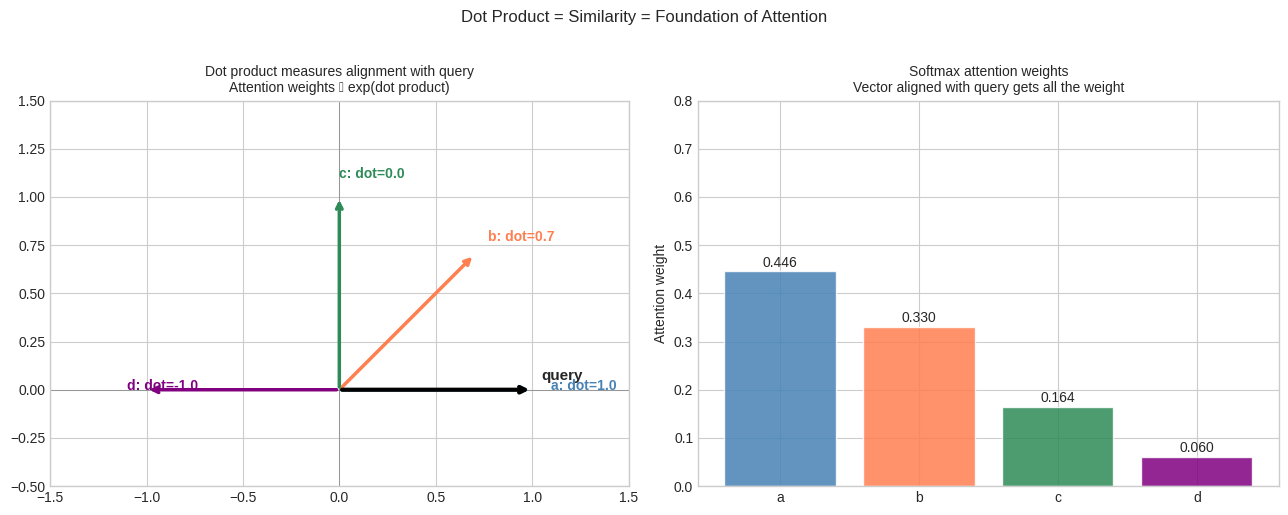

In [ ]:
# ── Plot 2: Dot product as cosine similarity (foundation of attention) ────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Vectors
vecs = {
    'a': np.array([1.0, 0.0]),
    'b': np.array([0.7, 0.7]),
    'c': np.array([0.0, 1.0]),
    'd': np.array([-1.0, 0.0]),
}
colors = {'a': 'steelblue', 'b': 'coral', 'c': 'seagreen', 'd': 'purple'}
query  = np.array([1.0, 0.0])

for name, v in vecs.items():
    axes[0].annotate('', xy=v, xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=colors[name], lw=2.5))
    axes[0].text(v[0]*1.1, v[1]*1.1, f'{name}: dot={np.dot(query, v):.1f}',
                 color=colors[name], fontsize=10, fontweight='bold')

axes[0].annotate('', xy=query, xytext=(0,0),
                 arrowprops=dict(arrowstyle='->', color='black', lw=3))
axes[0].text(query[0]*1.05, query[1]+0.05, 'query', fontsize=11, fontweight='bold')
axes[0].set_xlim(-1.5, 1.5); axes[0].set_ylim(-0.5, 1.5)
axes[0].set_aspect('equal')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_title('Dot product measures alignment with query\nAttention weights proportional to exp(dot product)', fontsize=10)

# Attention weights
dots    = np.array([np.dot(query, v) for v in vecs.values()])
weights = np.exp(dots) / np.exp(dots).sum()
names   = list(vecs.keys())
bars    = axes[1].bar(names, weights, color=list(colors.values()), edgecolor='white', alpha=0.85)
for bar, w in zip(bars, weights):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{w:.3f}', ha='center', fontsize=10)
axes[1].set_title('Softmax attention weights\n'
                   'Vector aligned with query gets all the weight', fontsize=10)
axes[1].set_ylabel('Attention weight')
axes[1].set_ylim(0, 0.8)

plt.suptitle('Dot Product = Similarity = Foundation of Attention', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 10. Exercises

**Exercise 1:** Implement matrix multiplication from scratch using only nested loops (no `@` or `np.dot`). Verify it matches `A @ B` on a 3×4 and 4×2 matrix. Then implement it using only `np.sum` and broadcasting (no loops). Compare execution time for a 100×100 matrix.


In [20]:
# Your code here


In [21]:
# Solution
import time

A = np.random.randn(3, 4)
B = np.random.randn(4, 2)

# Method 1: nested loops
def matmul_loops(A, B):
    m, n = A.shape
    n2, p = B.shape
    assert n == n2
    C = np.zeros((m, p))
    for i in range(m):
        for j in range(p):
            for k in range(n):
                C[i, j] += A[i, k] * B[k, j]
    return C

# Method 2: broadcasting (no loops)
def matmul_broadcast(A, B):
    # A: (m, n) -> (m, n, 1)
    # B: (n, p) -> (1, n, p)
    # product: (m, n, p)  sum over axis 1 -> (m, p)
    return np.sum(A[:, :, np.newaxis] * B[np.newaxis, :, :], axis=1)

C_loops = matmul_loops(A, B)
C_broad = matmul_broadcast(A, B)
C_numpy = A @ B

print('Loops matches @:', np.allclose(C_loops, C_numpy))
print('Broadcast matches @:', np.allclose(C_broad, C_numpy))

# Timing on 100x100
A_big = np.random.randn(100, 100)
B_big = np.random.randn(100, 100)

t0 = time.time(); _ = matmul_broadcast(A_big, B_big); t_broad = time.time()-t0
t0 = time.time(); _ = A_big @ B_big; t_numpy = time.time()-t0

print(f'\nBroadcast (100x100): {t_broad:.4f}s')
print(f'NumPy @    (100x100): {t_numpy:.6f}s')
print(f'NumPy @ is ~{t_broad/t_numpy:.0f}x faster — BLAS-optimized matrix ops')


Loops matches @: True
Broadcast matches @: True

Broadcast (100x100): 0.0057s
NumPy @    (100x100): 0.000369s
NumPy @ is ~15x faster — BLAS-optimized matrix ops


**Exercise 2:** Implement spectral normalization from scratch. Given a weight matrix $W$, compute its spectral norm (largest singular value $\sigma_1$) using the **power iteration method** (not full SVD — this is how PyTorch actually does it):

1. Initialize a random vector $v$
2. Iterate: $u = W v / \|W v\|$, then $v = W^T u / \|W^T u\|$
3. After convergence: $\sigma_1 \approx u^T W v$

Verify your result matches `np.linalg.svd(W)[1][0]`.


In [22]:
# Your code here


In [23]:
# Solution
def spectral_norm_power_iter(W, n_iter=20):
    v = np.random.randn(W.shape[1])
    v = v / np.linalg.norm(v)
    for _ in range(n_iter):
        u = W @ v;   u = u / np.linalg.norm(u)
        v = W.T @ u; v = v / np.linalg.norm(v)
    sigma_1 = u @ W @ v
    return sigma_1

W_test = np.random.randn(10, 8)

sigma_power = spectral_norm_power_iter(W_test)
sigma_svd   = np.linalg.svd(W_test, compute_uv=False)[0]

print(f'Power iteration: σ₁ = {sigma_power:.6f}')
print(f'Full SVD:        σ₁ = {sigma_svd:.6f}')
print(f'Match (atol=1e-4): {np.isclose(sigma_power, sigma_svd, atol=1e-4)}')
print('\nPyTorch uses this exact algorithm in torch.nn.utils.spectral_norm()')


Power iteration: σ₁ = 5.126122
Full SVD:        σ₁ = 5.126122
Match (atol=1e-4): True

PyTorch uses this exact algorithm in torch.nn.utils.spectral_norm()


**Exercise 3:** Build a mini attention mechanism from scratch using only NumPy:
- Input: a sequence of 4 words, each represented as a 6-dimensional vector
- Create random $W_Q$, $W_K$, $W_V$ projection matrices
- Compute $Q = X W_Q^T$, $K = X W_K^T$, $V = X W_V^T$
- Compute attention: $\text{softmax}(QK^T / \sqrt{d_k}) V$
- Print shapes at every step and explain what each represents


In [24]:
# Your code here


In [25]:
# Solution
np.random.seed(42)

seq_len, d_model, d_k, d_v = 4, 6, 4, 4

# Input: 4 word embeddings of dim 6
X = np.random.randn(seq_len, d_model)
print(f'X (input embeddings):  {X.shape}  — 4 tokens, each 6-dim')

# Projection matrices
W_Q = np.random.randn(d_k, d_model) * np.sqrt(1.0/d_model)
W_K = np.random.randn(d_k, d_model) * np.sqrt(1.0/d_model)
W_V = np.random.randn(d_v, d_model) * np.sqrt(1.0/d_model)

# Project
Q = X @ W_Q.T    # (4, 6) @ (6, 4) -> (4, 4)
K = X @ W_K.T    # (4, 6) @ (6, 4) -> (4, 4)
V = X @ W_V.T    # (4, 6) @ (6, 4) -> (4, 4)
print(f'Q (queries):           {Q.shape}  — each token as a query')
print(f'K (keys):              {K.shape}  — each token as a key')
print(f'V (values):            {V.shape}  — each token as a value')

# Attention scores
scores  = Q @ K.T / np.sqrt(d_k)  # (4, 4)
weights = np.exp(scores - scores.max(axis=-1, keepdims=True))
weights = weights / weights.sum(axis=-1, keepdims=True)
print(f'\nAttention weights:     {weights.shape}')
print('  weights[i, j] = how much token i attends to token j')
print(weights.round(3))

# Output
output = weights @ V   # (4, 4) @ (4, 4) -> (4, 4)
print(f'\nAttention output:      {output.shape}  — 4 tokens, each updated by context')
print('Each token now contains a weighted mix of all other tokens\' value vectors.')


X (input embeddings):  (4, 6)  — 4 tokens, each 6-dim
Q (queries):           (4, 4)  — each token as a query
K (keys):              (4, 4)  — each token as a key
V (values):            (4, 4)  — each token as a value

Attention weights:     (4, 4)
  weights[i, j] = how much token i attends to token j
[[0.214 0.114 0.157 0.515]
 [0.272 0.24  0.211 0.278]
 [0.054 0.034 0.68  0.231]
 [0.234 0.228 0.237 0.302]]

Attention output:      (4, 4)  — 4 tokens, each updated by context
Each token now contains a weighted mix of all other tokens' value vectors.


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
